In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_dir = "/home/yihelu/habitat-insect/examples/tutorials"
# data_file = "skokloster-castle.glb_3662_RandomAgent_0.json"
# data_file = "skokloster-castle.glb_1354_RandomAgent_0.json"
data_file = "skokloster-castle.glb_4171_RandomAgent_0.json"

# data_file = "skokloster-castle.glb_1354_GoalFollower_0.json"
# data_file = "skokloster-castle.glb_3662_GoalFollower_0.json"
# data_file = "skokloster-castle.glb_3662_ShortestPathFollowerAgent_0.json"

In [3]:
# Open the JSON file
with open(os.path.join(data_dir, data_file), 'r') as file:
    # Load the contents of the file into a dictionary
    data = json.load(file)

In [4]:
data.keys()

dict_keys(['trial_name', 'scene_id', 'episode_id', 'start_position', 'goal_position', 'final_distance_to_goal', 'success', 'spl', 'collision_count', 'position', 'rotation', 'pointgoal_with_gps_compass', 'is_collision', 'collision_left_right', 'collision_direction'])

In [5]:
pos_xy = np.array(data['position'])
rot = np.array(data['rotation'])
iscol = np.array(data['is_collision'])
colang = np.array(data['collision_direction'])
ang2goal = np.transpose(data['pointgoal_with_gps_compass'])[1]

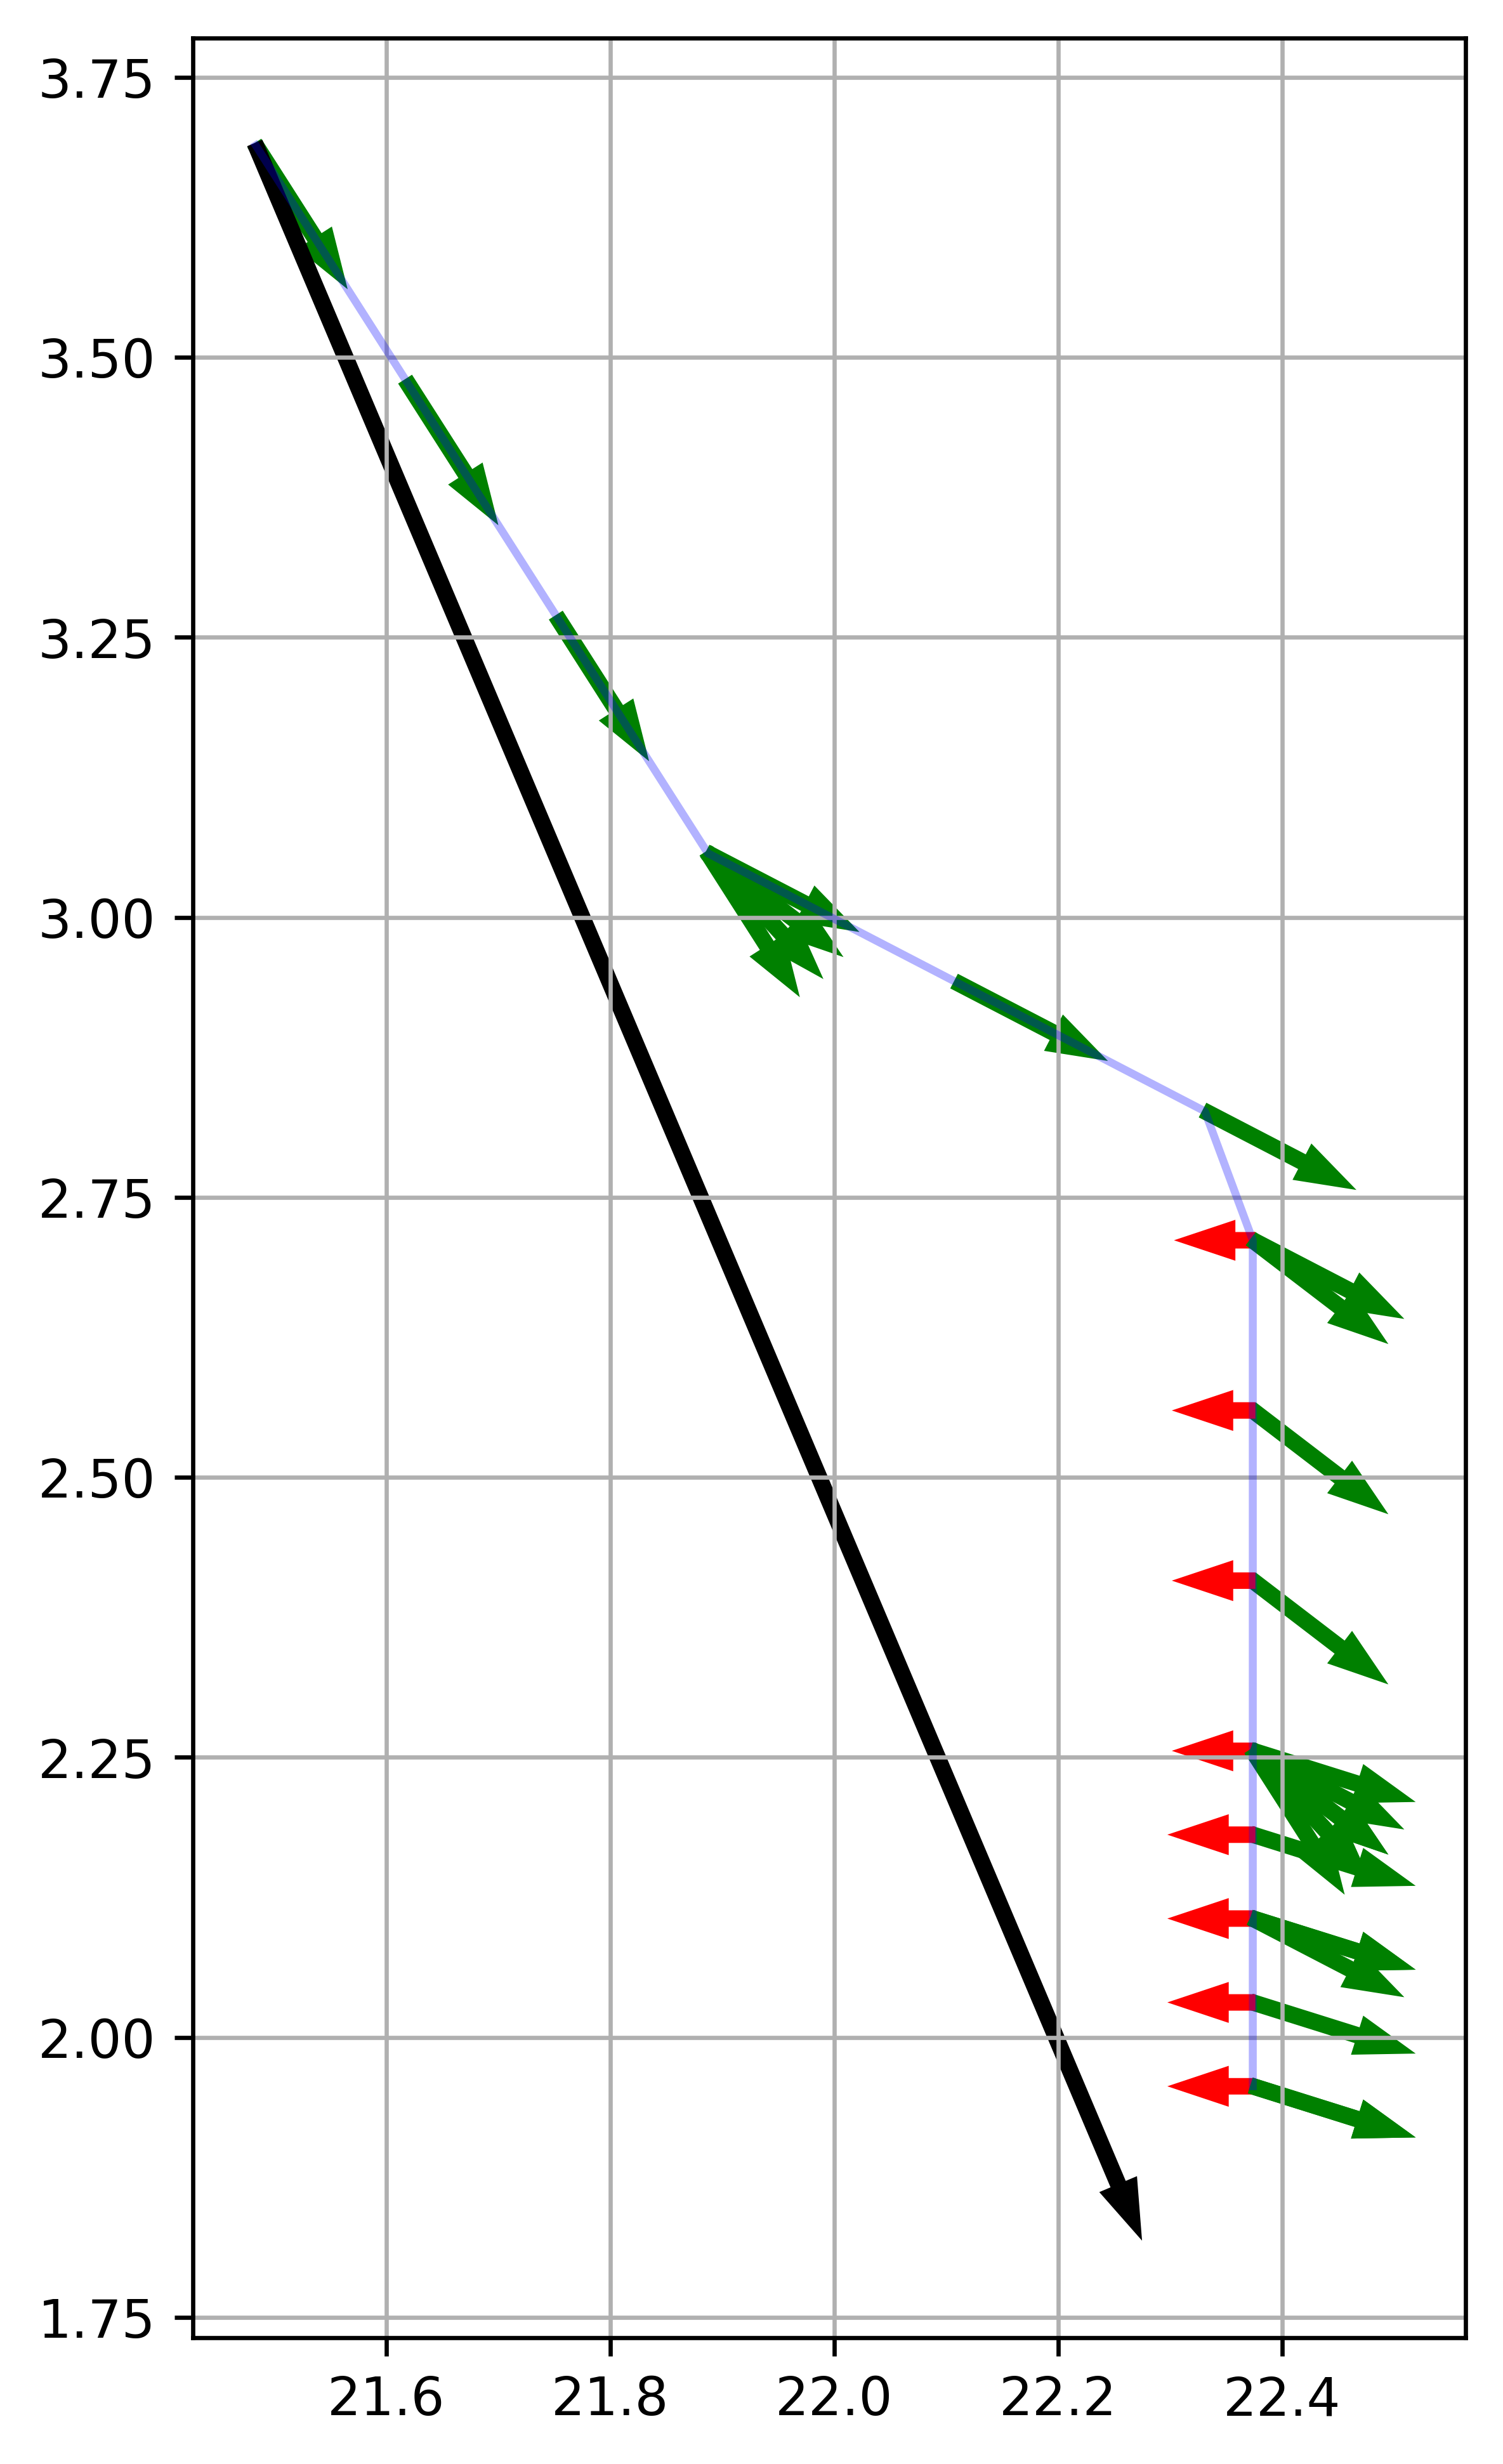

In [6]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=600)
ax.plot(*pos_xy.T, c='b', alpha=0.3)

arrow_size = 0.1
for x, y, r, ic, cl, ag in zip(pos_xy.T[0], pos_xy.T[1], rot, iscol, colang, ang2goal):
    # plot heading vector
    dx = np.cos(r) * arrow_size
    dy = np.sin(r) * arrow_size
    ax.arrow(x, y, dx, dy, color='g', width=0.01)
    # plot goal vector
#     gx = np.cos(ag + r) * arrow_size
#     gy = np.sin(ag + r) * arrow_size
#     ax.arrow(x, y, gx, gy, color='b', width=0.01)
    # plot collision direction
    if ic: 
        ax.arrow(x, y, *(cl * arrow_size), color='r', width=0.01)
        
# plot start to goal
ax.arrow(*data['start_position'], *(np.array(data['goal_position']) - np.array(data['start_position'])), 
         color='k', width=0.01)
ax.grid()
ax.set_aspect('equal')

13


Text(0.5, 1.0, 'left')

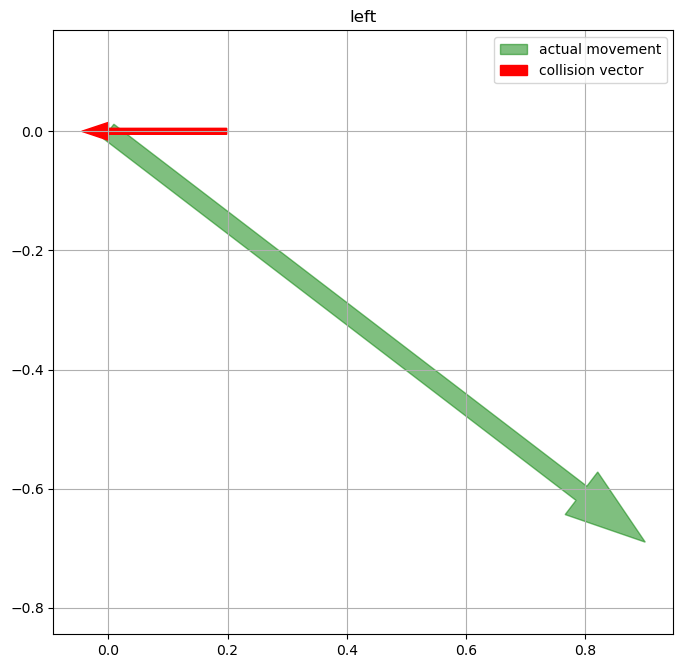

In [7]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=100)

# print(np.nonzero(iscol)[0])
colidx = np.random.choice(np.nonzero(iscol)[0])
print(colidx)

r, cl = rot[colidx], colang[colidx]

ax.arrow(0, 0, np.cos(r), np.sin(r), color='g', width=0.03, alpha=0.5, label='actual movement')
ax.arrow(*-cl, *cl, color='r', width=0.01, label='collision vector')

        
ax.legend()
ax.grid()
ax.axis('equal')
ax.set_title(data['collision_left_right'][colidx])